Import

In [123]:
import numpy as np
import matplotlib.pyplot as plt

In [124]:
x = np.arange(1, 501)

y = 2 * x + 5 + np.random.randn(len(x)) * 20

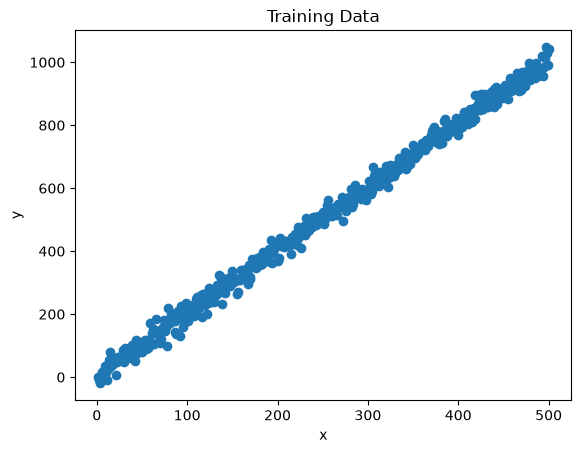

In [125]:
plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Training Data")
plt.show()

# Linear Regression

Linear Regression is a supervised learning algorithm used to predict continuous values.

$$
\hat{y} = w_1x + w_0
$$

In [126]:
def linear_regression(x,w0=0,w1=0):
    return np.dot(w1,x) + w0

## Cost Function

The cost function measures how well the model's predictions match the actual values.

$$
J(w,b) = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

Where:

- $J(w,b)$ = Cost
- $y_i$ = Actual value
- $\hat{y}_i$ = Predicted value
- $n$ = Number of samples

## Mean Squared Error (MSE)

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

Where:

- $y_i$ = Actual value
- $\hat{y}_i$ = Predicted value
- $n$ = Number of samples

In [127]:
def cost_function(y,y_pred):
    squared_error = (y - y_pred)**2
    return np.mean(squared_error)

## Gradient

The gradient shows how the cost function changes with respect to the model parameters.

### Gradient with respect to $w_1$

$$
\frac{\partial J}{\partial w_1}
=
-\frac{2}{n}\sum_{i=1}^{n}x_i(y_i-\hat{y}_i)
$$

### Gradient with respect to $w_0$

$$
\frac{\partial J}{\partial w_0}
=
-\frac{2}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)
$$

In [128]:
def gradian(y,y_pred,x):
    error = y - y_pred
    gradian_w1 = -2 * np.mean(x * error)
    gradian_w0 = -2 * np.mean(error)
    return gradian_w0 , gradian_w1

## Gradient Descent

Gradient Descent is an optimization algorithm used to minimize the cost function.

The parameters are updated in the opposite direction of the gradient:

$$
w_1 := w_1 - \alpha \frac{\partial J}{\partial w_1}
$$

$$
w_0 := w_0 - \alpha \frac{\partial J}{\partial w_0}
$$

Where:

- $\alpha$ = Learning Rate
- $\frac{\partial J}{\partial w_1}$ = Gradient of $w_1$
- $\frac{\partial J}{\partial w_0}$ = Gradient of $w_0$

The process is repeated for a number of iterations until the cost function is minimized.

In [129]:
def gradient_descent(learning_rate, iterations, y, x):
    w0 = 0
    w1 = 0

    y_pred = linear_regression(x, w0, w1)

    for i in range(iterations):

        w0_grad, w1_grad = gradian(y, y_pred, x)

        w0 -= learning_rate * w0_grad
        w1 -= learning_rate * w1_grad

        y_pred = linear_regression(x, w0, w1)
    return w0 , w1

In [133]:
w0 , w1 = gradient_descent(0.000001 , 100000 ,y ,x)
print(f"w0:{w0} , w1:{w1}")

w0:0.1374634021742902 , w1:2.019110193764979
